# Explicit method (FTCS) (Forward in Time Centered in Space method)
It's a finite difference method where the new state depends solely on the old state. The FTCS method is based on the forward Euler method in time (hence "forward in time") and central difference in space (hence "centered in space"), giving **first-order convergence in time** and **second-order convergence in space**.

# Heat equation: 1D metal heated in the middle
$$
\frac{\partial T}{\partial t} = c² \frac{\partial² T}{\partial x²},
$$
$$
T_t = c² \, T_{xx},
$$
$\Rightarrow$ *time evaluation = constant * curvature of the function (parabolic term)*.

## Discretization
We choose **j** as the index of the *time axis* and **i** as the index of the *space axis*. 

**Forward Difference in time:**
$$
T_{t} \approx \frac{T_{i,j+1} - T_{i,j}}{\Delta t} + \mathcal{O}(\Delta t).
$$
**Central Difference in space:**
$$
T_{xx} \approx \frac{T_{i+1,j} - 2 T_{i,j} + T_{i-1,j}}{\Delta x²} + \mathcal{O}(\Delta x²).
$$
Then,
$$
\Rightarrow \frac{T_{i,j+1} - T_{i,j}}{\Delta t} = c² \frac{T_{i+1,j} - 2 T_{i,j} + T_{i-1,j}}{\Delta x²},
$$
$$
T_{i,j+1} - T_{i,j} = r (T_{i+1,j} - 2 T_{i,j} + T_{i-1,j}),
$$
$$
T_{i, j+1} = (1-2r)T_{i,j} + r(T_{i-1,j}+T_{i+1,j}),
$$
where
$$
r = \frac{c^2 \Delta t}{\Delta x^2}.
$$

---

## Von-Neumann Stability Analysis
It introduces a perturbation (*Fourier mode (sine wave)*) into the multivariate function. We can write the perturbation as,
$$
T_{i,j} = A^j e^{ \textbf{i} k x_i}.
$$

Then, we replace this perturbation on the main equation we got,
$$T_{i, j+1} = (1-2r)T_{i,j} + r(T_{i-1,j}+T_{i+1,j}),$$
$$A^{j+1} e^{ \textbf{i} k x_i} = A^{j}\left[ (1-2r)e^{ \textbf{i} k x_i} + r(e^{ \textbf{i} k x_{i-1}} + e^{ \textbf{i} k x_{i+1}}) \right],$$
$$\frac{A^{j+1}}{A^{j}} = e^{ \textbf{-i} k x_i}\left[  (1-2r)e^{ \textbf{i} k x_i} + r(e^{ \textbf{i} k x_{i-1}} + e^{ \textbf{i} k x_{i+1}}) \right],$$
$$A = (1 - 2r) + r(e^{\textbf{i} k (x_{i+1} - x_i)} + e^{\textbf{-i} k (x_{i} - x_{i-1})}),$$

$$
\Rightarrow A = 1 - 2r + 2r \cos(k \Delta x).
$$
where $x_{i+1} - x_i = x_{i} - x_{i-1} = \Delta x.$

### Stable methods:
The amplitude of the perturbation should decrease for the method to be stable.
$$
\frac{|A^{j+1}|}{|A^{j}|} \le 1, \forall k.
$$
$$
\Rightarrow |1 - 2r + 2r \cos(k \Delta x)| \le 1.
$$

Since $\cos(k \Delta x) \in [-1, 1]$, the most restrictive condition occurs at the minimum value of the amplification factor. This happens at $\cos(k \Delta x) = -1.$

Thus, we impose the stability condition on this worst-case mode:
$$
-1 \le 1 - 2r + 2r(-1) \le 1,
$$
$$
-1 \le 1 - 4r \le 1,
$$
$$
-2 \le -4r \le 0,
$$
$$
0 \le r \le \frac{1}{2}.
$$

Finally, to have a stable solution,
$$ r = \frac{c² \Delta t}{\Delta x²} \le \frac{1}{2}.$$

---


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# This is for 3D visualisation
from mpl_toolkits.mplot3d import Axes3D

### 1. Domain Definition (grid creation):

In [2]:
# Steps

k = 0.025 # Time step -> delta_t
h = 0.1 # Step size -> delta_x

# Diffusion coefficient:
c_2 = 0.5

# Define the r factor
r_factor = c_2*k/h**2 #should be less than 0.5 to have stable solutions
print(r_factor)

1.2499999999999998


In [3]:
# Limit for the spatial vector
a = 1.0

# Limit for the time vector
b = 0.5

# Axes
# Spatial axis
x = np.arange(0., a + h , h)

# Time axis, rounding it to 3 figs. is for plotting only
t = np.arange(0., b + k , k).round(5)

print(x.shape)
print(t.shape)

(11,)
(21,)


### 2. Set up ICs/BCs:

In [4]:
# Initial conditions
ics = np.sin(np.pi*x) # this is the initial T at t=0

# Boundary Conditions 
bcs = [0., 0.] # T = 0 at x=0, and x=a

### 3. Create an empty solution (sln) matrix for $T(x,t)$

In [5]:
# Matrix T
n = len(x)
m = len(t)
#print(n, m)

# Empty matrix with the correct size
T = np.zeros((n, m))

print(T.shape)

#print(T)

(11, 21)


### 4. Fill up the matrix elements with the ICs/BCs:

In [6]:
# Fill up the initial conditions
T[:, 0] = ics

# Fill up the boundary conditions
T[0 , :] = bcs[0]
T[-1, :] = bcs[1]

print(T.round(4).T)

[[0.     0.309  0.5878 0.809  0.9511 1.     0.9511 0.809  0.5878 0.309
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     0. 

### 5. Fill up the inner elements of the matrix using our explicit formula:

$$T_{i, j+1} = (1-2r)T_{i,j} + r(T_{i-1,j}+T_{i+1,j})$$

In [7]:
# outler loop (time loop -> index j)

for j in range(1, m): # From 1 as we already have the ICs
    
    # inner loop (spatial loop -> index i)
    
    for i in range(1, n - 1): # From 1 to n-1 as we already have the BCs set
        # Explicit formula
        T[i, j] = (1 - 2*r_factor)*T[i, j-1] + r_factor*(T[i-1, j-1] + T[i+1, j-1])
        

In [8]:
print(T.round(3).T)

[[0.    0.309 0.588 0.809 0.951 1.    0.951 0.809 0.588 0.309 0.   ]
 [0.    0.271 0.516 0.71  0.835 0.878 0.835 0.71  0.516 0.271 0.   ]
 [0.    0.238 0.453 0.623 0.733 0.77  0.733 0.623 0.453 0.238 0.   ]
 [0.    0.209 0.397 0.547 0.643 0.676 0.643 0.547 0.397 0.209 0.   ]
 [0.    0.183 0.349 0.48  0.564 0.593 0.564 0.48  0.349 0.183 0.   ]
 [0.    0.161 0.306 0.421 0.495 0.521 0.495 0.421 0.306 0.161 0.   ]
 [0.    0.141 0.269 0.37  0.435 0.457 0.435 0.37  0.269 0.141 0.   ]
 [0.    0.124 0.236 0.324 0.381 0.401 0.381 0.324 0.236 0.124 0.   ]
 [0.    0.109 0.207 0.285 0.335 0.352 0.335 0.285 0.207 0.109 0.   ]
 [0.    0.095 0.182 0.25  0.294 0.309 0.294 0.25  0.182 0.095 0.   ]
 [0.    0.084 0.159 0.219 0.258 0.271 0.258 0.219 0.159 0.084 0.   ]
 [0.    0.074 0.14  0.193 0.226 0.238 0.226 0.193 0.14  0.074 0.   ]
 [0.    0.065 0.123 0.169 0.199 0.209 0.199 0.169 0.123 0.065 0.   ]
 [0.    0.057 0.108 0.148 0.174 0.183 0.174 0.148 0.108 0.057 0.   ]
 [0.    0.05  0.095 0.13  0.153 0.

### 6. Plotting the solutions for $T(x,t)$

#### A. Temperature vs. Positon space:

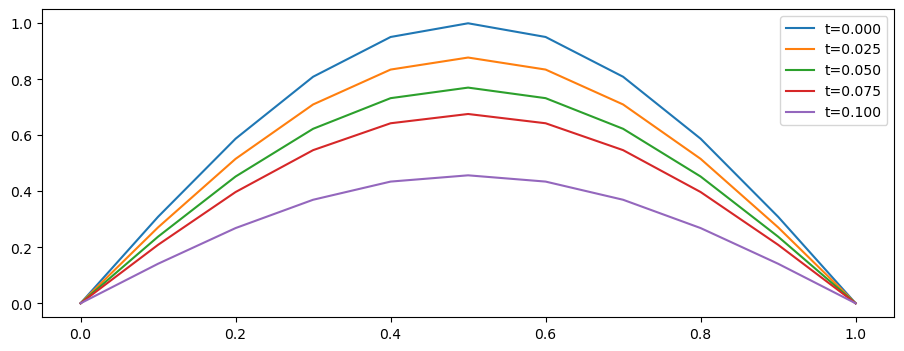

In [9]:
# Fig environment

plt.figure(figsize=(11,4))

plt.plot(x, T[:, 0], label = 't=0.000')

plt.plot(x, T[:, 1], label = 't=0.025')

plt.plot(x, T[:, 2], label = 't=0.050')

plt.plot(x, T[:, 3], label = 't=0.075')

plt.plot(x, T[:, 6], label = 't=0.100')

plt.legend()

plt.show()

The rate of change depends on curvature.

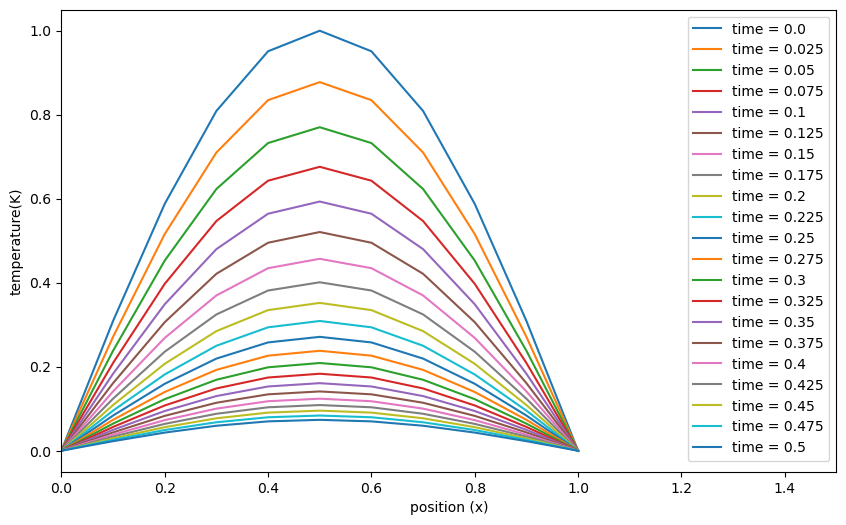

In [10]:
plt.figure(figsize=(10,6))

for j in range(m):
    plt.plot(x, T[:, j])

plt.xlim(0,1.5)

plt.xlabel("position (x)")
plt.ylabel("temperature(K)")
    
plt.legend([f'time = {time_value}' for time_value in t], loc=1)
plt.show()

#### B. Maximum temperature vs. time.

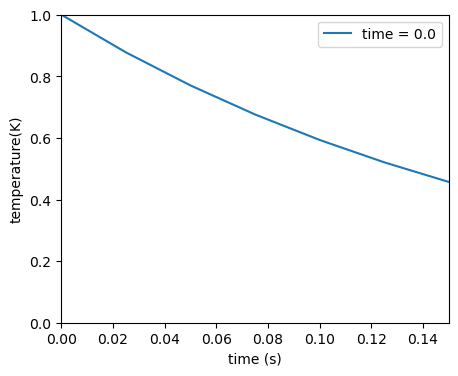

In [11]:
plt.figure(figsize=(5,4))

plt.plot(t, T[int(x.shape[0])//2 , :])

plt.xlim(0,0.15)
plt.ylim(0,1)

plt.xlabel("time (s)")
plt.ylabel("temperature(K)")
    
plt.legend([f'time = {time_value}' for time_value in t], loc=1)
plt.show()

#### C. Temperature surface projection:

In [12]:
# Create 2D grid using meshgrid
x_grid, t_grid = np.meshgrid(x, t)

print(x_grid.shape, t_grid.shape, T.T.shape)

(21, 11) (21, 11) (21, 11)


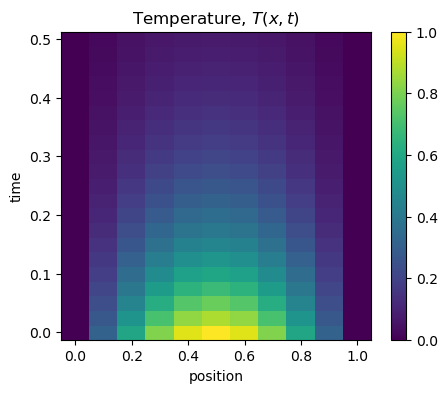

In [13]:
plt.figure(figsize=(5,4))

# Surface
z_temp = plt.pcolor(x_grid, t_grid, T.T, cmap = 'viridis')

plt.xlabel("position")

plt.ylabel("time")

plt.title("Temperature, $T(x, t)$")

plt.colorbar(z_temp)

plt.show()

#### D. Temperature surface rendering:

/tmp/ipykernel_197600/2839097452.py:12: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 500x400 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(z_temp, ax=ax)


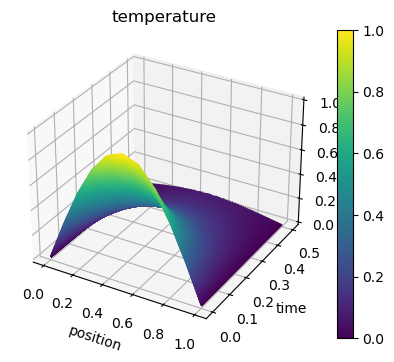

In [14]:
plt.figure(figsize=(5,4))

ax  = plt.axes(projection='3d')

ax.contour3D(x_grid, t_grid, T.T, 500, cmap = 'viridis')

plt.xlabel("position")
plt.ylabel("time")

plt.title("temperature")

plt.colorbar(z_temp, ax=ax)

plt.show()